# Портрет событий со скором 0.8–0.9

Полоса `0. 8< score <= 0.9` — переходная: сеть уже не считает событие мюонным, но
ещё не относит к нейтринным. Ниже — как выглядят события этой полосы в четырёх
доменах: экспериментальные данные и три класса МК.

Всё построено читалкой `inference_v2.reader` по одному чекпойнту.

**Отбор.** Только события, которых модель не видела: для МК снимается обучающий
NPY-датасет (`NOT_TRAINED`), для эксперимента — немеченая цель доменной адаптации
(`NOT_DA_TARGET`) и прогоны с зафиксированными неисправностями (`NOT_EXCLUDED`).
Плюс общий кат качества `H8S3` — не меньше 8 сигнальных хитов на не меньше чем
3 струнах.

**Что смотрим.** Сырые хиты и хиты, отобранные sig-noise фильтром; агрегаты на
событие; множественность; для МК — истина по первичной частице.

In [1]:
import os, sys, time
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
sys.path.insert(0, "/home/albert/Baikal2025")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200)

from inference_v2 import reader

CHECKPOINT = ("260816_2250_da_nu_classifier_exp_full_E1_lambda0.01_FIXED_sn256"
              "@best_da_model")
BAND = "p.score > 0.8 AND p.score <= 0.9"

# Домен -> (источник, условия, знаменатель прореживания по частям).
DOMAINS = {
    "exp_full":   ("exp_full",  [reader.H8S3, reader.NOT_DA_TARGET,
                                 reader.NOT_EXCLUDED, BAND], 1),
    "muatm":      ("mc_merged", [reader.H8S3, reader.NOT_TRAINED, BAND,
                                 "e.data_class = 'muatm_2020'"], 1),
    "nuatm":      ("mc_merged", [reader.H8S3, reader.NOT_TRAINED, BAND,
                                 "e.data_class = 'nuatm_2020'"], 1),
    "nue2":       ("mc_merged", [reader.H8S3, reader.NOT_TRAINED, BAND,
                                 "e.data_class = 'nue2_2020'"], 1),
}
COLOURS = {"exp_full": "#d62728", "muatm": "#1f77b4",
           "nuatm": "#2ca02c", "nue2": "#ff7f0e"}


def selection(name, thinned=True):
    """Условия отбора домена; при `thinned` — с прореживанием по частям."""
    source, conditions, modulus = DOMAINS[name]
    conditions = list(conditions)
    if thinned and modulus > 1:
        # hash() в DuckDB детерминирован между процессами — проверено, — так что
        # это воспроизводимая выборка частей, а не случайная при каждом запуске.
        conditions.append(f"hash(l.part_key) % {modulus} = 0")
    return source, conditions

## 1. Выгрузка

Полоса узкая, но события в ней разбросаны по файлам очень по-разному, и это решает,
сколько будет стоить чтение.

`exp_full` и `nue2` берутся **целиком**: их события кучные — 57 и 23 на часть.
`nuatm` прорежен вдвое по частям, `muatm` — в десять раз, иначе пришлось бы
распаковывать чанки семи с половиной тысяч частей ради двух событий в каждой.

**Что такое прореживание по частям.** Отбирается детерминированное подмножество
частей (`hash(part_key) % k = 0`), и внутри них берутся **все** события полосы. Это
кластерная выборка: оценки распределений несмещённые, но события внутри части —
соседи по файлу, поэтому эффективная статистика меньше номинальной. Для формы
гистограмм этого достаточно; для точных долей — нет.

Колонка `переплата` в отчёте показывает, во сколько раз больше хитов пришлось
поднять с диска, чем оставить. Это цена gzip-сжатия при разреженном отборе.

Полоска прогресса берётся из `r.count()` — он даёт итог одним агрегатным запросом
за секунды, — и обновляется по обратному вызову `progress=`, который читалка зовёт
на каждой прочитанной части. Сама она ничего не печатает: это библиотека, и печать
из неё ломала бы логи и тесты.


In [2]:
from tqdm.auto import tqdm


def streaming(r, where, **kwargs):
    """Чанки читалки с полоской прогресса.

    Читалка сама ничего не печатает -- она библиотека, и печать из неё портила бы
    логи и тесты. Вместо этого она зовёт `progress(...)` с описанием состояния, а
    что с ним делать, решает вызывающий. Здесь -- tqdm.

    `count()` даёт итог заранее, чтобы полоска была полоской, а не спиннером.
    Оговорка: маски (`whole_events`) в SQL не выражаются, поэтому при них реально
    прочитанных событий будет меньше, чем обещал `count()`, и полоска не дойдёт до
    конца. Для mc_reco это около 12 %.
    """
    total = r.count(where=where)
    labels = {"querying": "запрос", "training": "таблица обучения",
              "done": "готово"}
    with tqdm(total=total["events"], unit=" соб", leave=True) as pbar:
        def report(state):
            pbar.set_description(labels.get(
                state.stage, f"часть {state.parts}/{total['parts']}"))
            if state.events:
                pbar.n = state.events
            pbar.refresh()
        yield from r.stream(where=where, progress=report, **kwargs)


def load(name, budget_mb=512):
    source, conditions = selection(name)
    r = reader.open(source, checkpoint=CHECKPOINT)
    t0 = time.time()
    events, hits, read = [], [], 0
    for chunk in streaming(r, conditions, budget_mb=budget_mb):
        r.verify(chunk)                      # сверка адресации на каждом чанке
        offset = sum(len(e) for e in events)
        piece = chunk.hits.copy()
        piece["event"] = piece["event"].to_numpy() + offset
        events.append(chunk.events); hits.append(piece)
        read += chunk.meta.get("hits_read", 0)
    ev = pd.concat(events, ignore_index=True) if events else pd.DataFrame()
    hi = pd.concat(hits, ignore_index=True) if hits else pd.DataFrame()
    return ev, hi, dict(домен=name, событий=len(ev), хитов=len(hi),
                        частей=ev.part_key.nunique() if len(ev) else 0,
                        переплата=round(read / max(len(hi), 1), 1),
                        секунд=round(time.time() - t0, 1))

EV, HITS, report = {}, {}, []
for name in DOMAINS:
    EV[name], HITS[name], info = load(name)
    report.append(info)
pd.DataFrame(report)

  0%|          | 0/516 [00:00<?, ? соб/s]

  0%|          | 0/4504 [00:00<?, ? соб/s]

  0%|          | 0/5758 [00:00<?, ? соб/s]

  0%|          | 0/17073 [00:00<?, ? соб/s]

,домен,событий,хитов,частей,переплата,секунд
0,exp_full,516,37651,23,13.1,32.4
1,muatm,4504,376213,3609,8.6,283.3
2,nuatm,5758,457996,1706,39.0,221.0
3,nue2,17073,1390613,400,242.4,160.9


### Насколько эта полоса населена

Сама по себе доля событий, попадающих в 0.8–0.9, уже говорит о домене: для мюонов
это далёкий хвост, для нейтрино — заметная часть распределения.

In [3]:
from inference_v2.reader import query, spec

def count(name, conditions):
    source = DOMAINS[name][0]
    ck = reader.open_checkpoint(CHECKPOINT)
    con = query.connect(ck, source)
    try:
        sql, tables = query.build_sql(con, spec.SOURCES[source], ck, conditions)
        for alias, frame in tables.items():
            con.register(alias, frame)
        return con.execute(
            f"SELECT count(*) FROM ({sql.replace(' ORDER BY p.event_fk', '')})"
        ).fetchone()[0]
    finally:
        con.close()

rows = []
for name in DOMAINS:
    source, full = selection(name, thinned=False)
    base = [c for c in full if c != BAND]
    total, in_band = count(name, base), count(name, full)
    rows.append({"домен": name,
                 "прошло H8S3": total,
                 "в полосе 0.6–0.8": in_band,
                 "доля полосы, %": round(100 * in_band / total, 3),
                 "взято в выборку": len(EV[name]),
                 "прорежено в": DOMAINS[name][2]})
pd.DataFrame(rows)

,домен,прошло H8S3,в полосе 0.6–0.8,"доля полосы, %",взято в выборку,прорежено в
0,exp_full,1049948,516,0.049,516,1
1,muatm,23167718,4504,0.019,4504,1
2,nuatm,531066,5758,1.084,5758,1
3,nue2,1373194,17073,1.243,17073,1


## 2. Как читать рисунки

Все гистограммы строятся **на общих бинах** и нормируются на площадь. Иначе домены
разного размера сравнивать нельзя: `muatm` в десять раз больше `exp_full`, и без
нормировки видна была бы только разница в статистике.

Диапазон берётся по объединению центральных 99.5 % каждого домена, чтобы один выброс
не сплющил картинку.

In [4]:
def overlay(frames, column, ax, bins=None, logx=False, logy=True, span=None,
            quantile=0.9975):
    """Гистограммы всех доменов на общих бинах, нормированные на площадь.

    `bins=None` — выбрать по данным, число — взять ровно столько.

    Счётчики (хиты, струны, модули) целые, и бины, которые этого не учитывают,
    кладут два целых значения в один бин и ни одного в соседний: выходит
    гребёнка, похожая на структуру, которой нет. Поэтому при `bins=None` для
    целых величин ставится по бину на каждое целое.

    Раньше эта ветка срабатывала безусловно, и явный `bins=100` молча ничего не
    менял: 37 бинов и при 70, и при 500. Теперь заданное число всегда выигрывает.
    """
    series = {}
    for name, frame in frames.items():
        if column not in frame:
            continue
        values = pd.to_numeric(frame[column], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        if logx:
            values = values[values > 0]
        if len(values):
            series[name] = values
    if not series:
        ax.axis("off")
        return ax

    if span is None:
        lo = min(np.quantile(v, 1 - quantile) for v in series.values())
        hi = max(np.quantile(v, quantile) for v in series.values())
        span = (lo, hi) if hi > lo else (lo - 1, lo + 1)

    integral = all(np.all(np.equal(np.mod(v, 1), 0)) for v in series.values())
    auto_integer = (bins is None and integral and not logx
                    and span[1] - span[0] <= 300)
    n_bins = 70 if bins is None else int(bins)

    if auto_integer:
        edges = np.arange(np.floor(span[0]) - 0.5, np.ceil(span[1]) + 1.5)
    elif logx:
        edges = np.geomspace(max(span[0], 1e-9), span[1], n_bins + 1)
    else:
        edges = np.linspace(span[0], span[1], n_bins + 1)

    for name, values in series.items():
        ax.hist(values, bins=edges, density=True, histtype="step", lw=1.7,
                label=f"{name} ({len(values):,})", color=COLOURS.get(name))
    ax.set_xlabel(column)
    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.legend(fontsize=7)
    return ax



def panel(frames, columns, ncols=3, size=(4.4, 3.0), **kwargs):
    columns = list(columns)
    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(size[0] * ncols, size[1] * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, column in zip(axes, columns):
        opts = kwargs.get(column, {}) if isinstance(kwargs.get(column), dict) else {}
        overlay(frames, column, ax, **{**{k: v for k, v in kwargs.items()
                                          if not isinstance(v, dict)}, **opts})
    for ax in axes[len(columns):]:
        ax.axis("off")
    fig.tight_layout()
    return fig

## 3. Сырые хиты

Всё, что записано в событии, до фильтра sig-noise. Заряд в фотоэлектронах, время в
наносекундах и **центрировано по событию** (конвертер вычитает среднее, так что
абсолютного времени в файле нет), координаты в метрах относительно центра кластера.

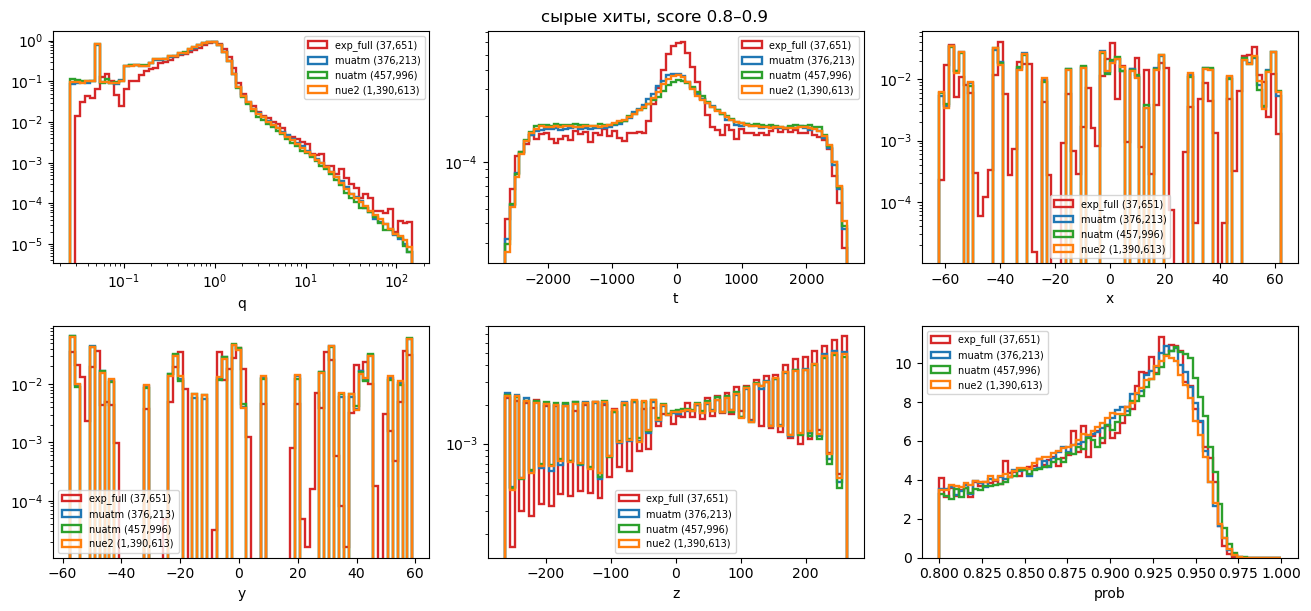

In [14]:
fig = panel(HITS, ["q", "t", "x", "y", "z", "prob"], ncols=3,
            q={"logx": True}, prob={"logy": False, "span": [0.8,1.0]})
fig.suptitle("сырые хиты, score 0.8–0.9", y=1.01)
plt.show()

## 4. Хиты, отобранные sig-noise

Те же величины, но только по хитам с `prob > 0.8` — именно они попадают в
классификатор.

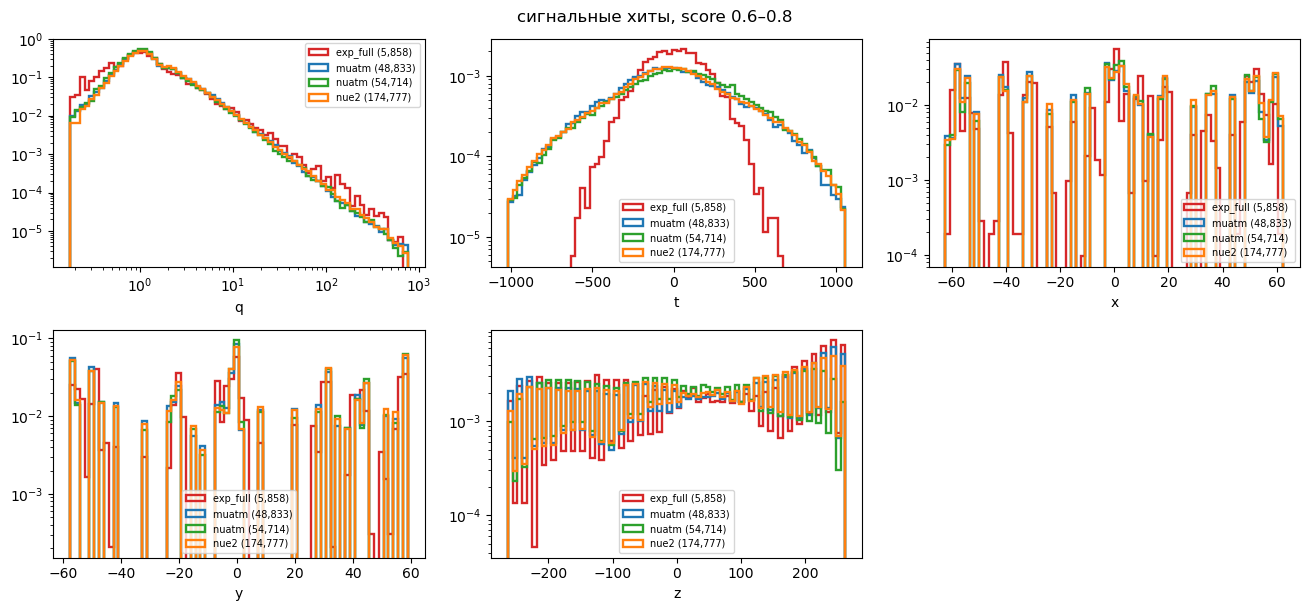

In [6]:
SIG = {name: frame[frame.is_sig] for name, frame in HITS.items()}
fig = panel(SIG, ["q", "t", "x", "y", "z"], ncols=3, q={"logx": True})
fig.suptitle("сигнальные хиты, score 0.6–0.8", y=1.01)
plt.show()

## 5. Агрегаты на событие

Каждый хит принадлежит событию через `hits.event`. Считаем на событие среднее,
разброс и размах по каждой величине — отдельно для сырых и для сигнальных хитов.

In [7]:
VARS = ["q", "t", "x", "y", "z"]


def dz_dt(hits, n_events, prefix):
    """Наклон dz/dt и качество прямой, по событиям.

    МНК-регрессия z по t. Сумматоры считаются по центрированным внутри события
    величинам: прямая формула через sum(t^2) - sum(t)^2/n есть разность больших
    близких чисел и во float32 теряет значащие разряды. Здесь float64 намеренно —
    в отличие от остальных агрегатов, где float32 достаточно.

    Возвращает:
        {prefix}_dzdt      наклон, м/нс (c = 0.2998 м/нс)
        {prefix}_dzdt_r2   доля объяснённой дисперсии z, 0..1
        {prefix}_dzdt_rms  СКО невязок по z, м
        {prefix}_dzdt_n    сколько хитов участвовало

    NaN там, где фит не определён: меньше трёх хитов, либо все хиты в один момент
    (S_tt = 0), либо нет разброса по глубине (S_zz = 0, тогда неопределён R^2).

    Осмысленно только для сигнальных хитов: шумовые размазаны по всему окну и дают
    R^2 около нуля на любом событии.
    """
    index = pd.RangeIndex(n_events)
    out = pd.DataFrame(index=index)
    if hits.empty:
        for suffix in ("dzdt", "dzdt_r2", "dzdt_rms", "dzdt_n"):
            out[f"{prefix}_{suffix}"] = np.nan
        return out

    frame = pd.DataFrame({
        "event": hits["event"].to_numpy(),
        "t": hits["t"].to_numpy(np.float64),
        "z": hits["z"].to_numpy(np.float64),
    })
    grouped = frame.groupby("event")
    t = frame["t"] - grouped["t"].transform("mean")
    z = frame["z"] - grouped["z"].transform("mean")

    centred = pd.DataFrame({"event": frame["event"],
                            "tt": t * t, "tz": t * z, "zz": z * z})
    sums = centred.groupby("event").sum()
    n = grouped.size()

    s_tt, s_tz, s_zz = sums["tt"], sums["tz"], sums["zz"]
    enough = n >= 3
    slope = (s_tz / s_tt).where(enough & (s_tt > 0))
    r2 = (s_tz ** 2 / (s_tt * s_zz)).where(enough & (s_tt > 0) & (s_zz > 0))
    rms = np.sqrt(((s_zz - slope * s_tz) / n).clip(lower=0))

    out[f"{prefix}_dzdt"] = slope.reindex(index)
    out[f"{prefix}_dzdt_r2"] = r2.clip(0, 1).reindex(index)
    out[f"{prefix}_dzdt_rms"] = rms.reindex(index)
    out[f"{prefix}_dzdt_n"] = n.reindex(index, fill_value=0)
    return out


def aggregate(hits, n_events, prefix):
    grouped = hits.groupby("event")
    out = pd.DataFrame(index=pd.RangeIndex(n_events))
    out[f"{prefix}_n_hits"] = grouped.size().reindex(out.index, fill_value=0)
    out[f"{prefix}_n_strings"] = (grouped["string"].nunique()
                                  .reindex(out.index, fill_value=0))
    out[f"{prefix}_n_channels"] = (grouped["channel"].nunique()
                                   .reindex(out.index, fill_value=0))
    stats = grouped[VARS].agg(["mean", "std", "min", "max"])
    for var in VARS:
        for stat in ("mean", "std"):
            out[f"{prefix}_{var}_{stat}"] = stats[(var, stat)].reindex(out.index)
        out[f"{prefix}_{var}_ptp"] = (stats[(var, "max")] - stats[(var, "min")]
                                      ).reindex(out.index)
    return out.join(dz_dt(hits, n_events, prefix))


AGG = {}
for name in DOMAINS:
    raw = aggregate(HITS[name], len(EV[name]), "raw")
    sig = aggregate(HITS[name][HITS[name].is_sig], len(EV[name]), "sig")
    AGG[name] = EV[name].join(raw).join(sig)

# Знак наклона задаётся ориентацией оси z, которую я не проверял. Атмосферные
# мюоны идут сверху вниз практически все, поэтому их медиана и задаёт соглашение.
print(pd.DataFrame({
    "медиана sig_dzdt, м/нс": {k: v.sig_dzdt.median() for k, v in AGG.items()},
    "медиана sig_dzdt_r2":    {k: v.sig_dzdt_r2.median() for k, v in AGG.items()},
    "доля с R2 > 0.8":        {k: (v.sig_dzdt_r2 > 0.8).mean() for k, v in AGG.items()},
    "не определился":         {k: v.sig_dzdt.isna().mean() for k, v in AGG.items()},
}).round(4))


          медиана sig_dzdt, м/нс  медиана sig_dzdt_r2  доля с R2 > 0.8  не определился
exp_full                  0.0646               0.1293           0.0039             0.0
muatm                     0.0640               0.1320           0.0049             0.0
nuatm                     0.0708               0.1629           0.0019             0.0
nue2                      0.0662               0.1420           0.0024             0.0


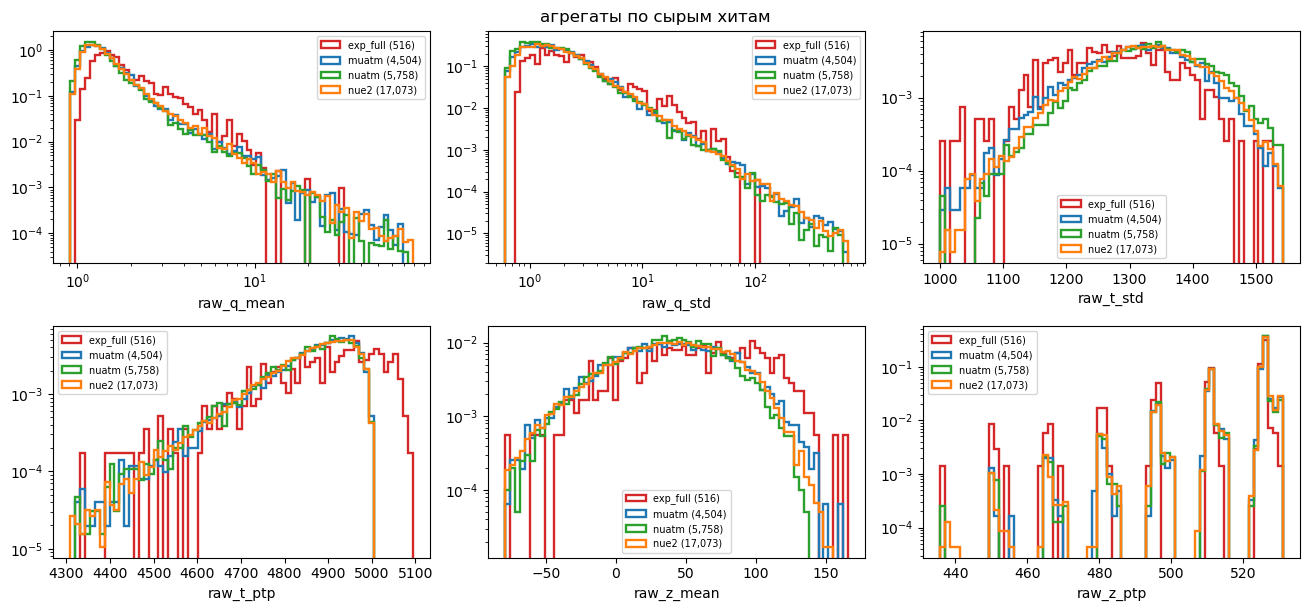

In [8]:
fig = panel(AGG, ["raw_q_mean", "raw_q_std", "raw_t_std", "raw_t_ptp",
                  "raw_z_mean", "raw_z_ptp"], ncols=3,
            raw_q_mean={"logx": True}, raw_q_std={"logx": True})
fig.suptitle("агрегаты по сырым хитам", y=1.01)
plt.show()

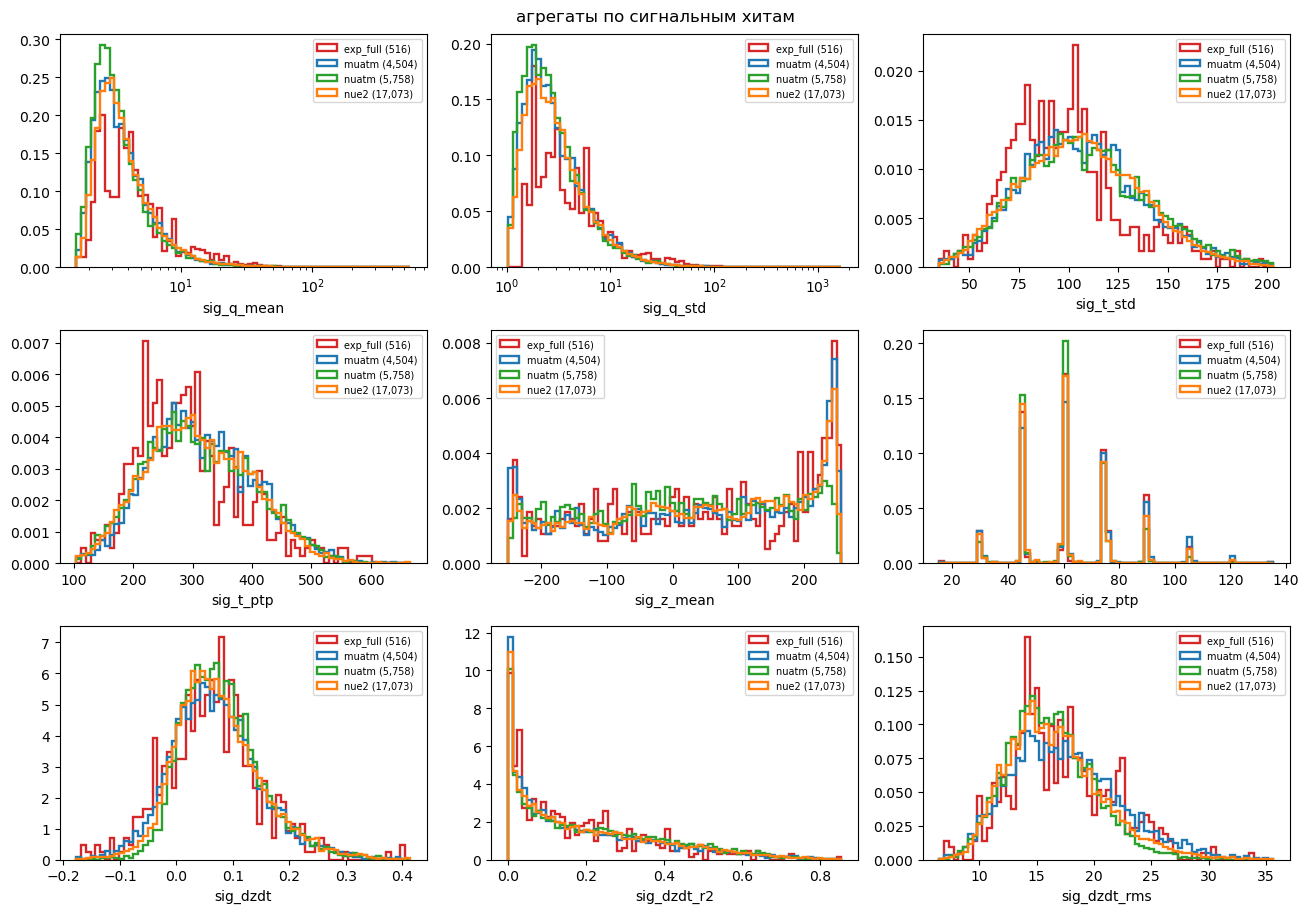

In [9]:
fig = panel(AGG, [
      "sig_q_mean", "sig_q_std", "sig_t_std", 
      "sig_t_ptp", "sig_z_mean", "sig_z_ptp",
      "sig_dzdt", "sig_dzdt_r2", "sig_dzdt_rms",
      ], ncols=3,
            sig_q_mean={"logx": True}, sig_q_std={"logx": True}, logy=False)
fig.suptitle("агрегаты по сигнальным хитам", y=1.01)
plt.show()

## 6. Множественность

Сколько хитов, струн и модулей задействовано — до фильтра и после.

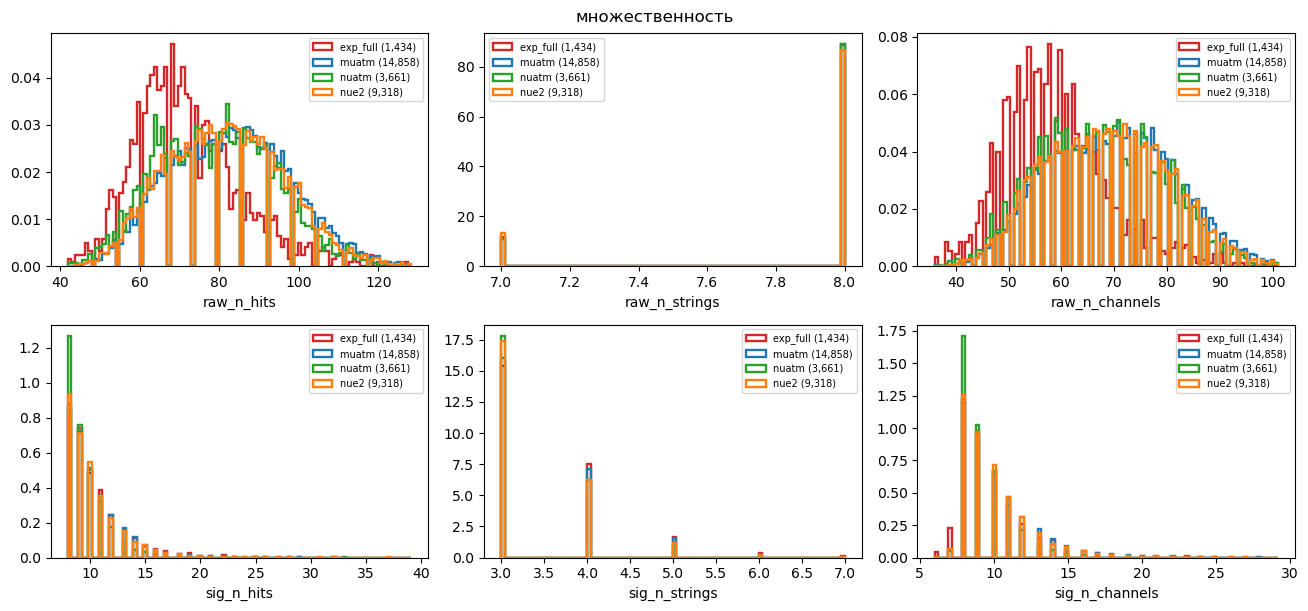

In [35]:
fig = panel(AGG, [
    "raw_n_hits", "raw_n_strings", "raw_n_channels",
    "sig_n_hits", "sig_n_strings", 
    "sig_n_channels"
    ], ncols=3, bins=100, logy=False)
fig.suptitle("множественность", y=1.01)
plt.show()

## 7. Истина МК

`prime_prty` есть только у симуляции, поэтому здесь три класса без эксперимента.
`theta` — зенитный угол первичной частицы: 180° это строго снизу вверх, 0° — сверху.

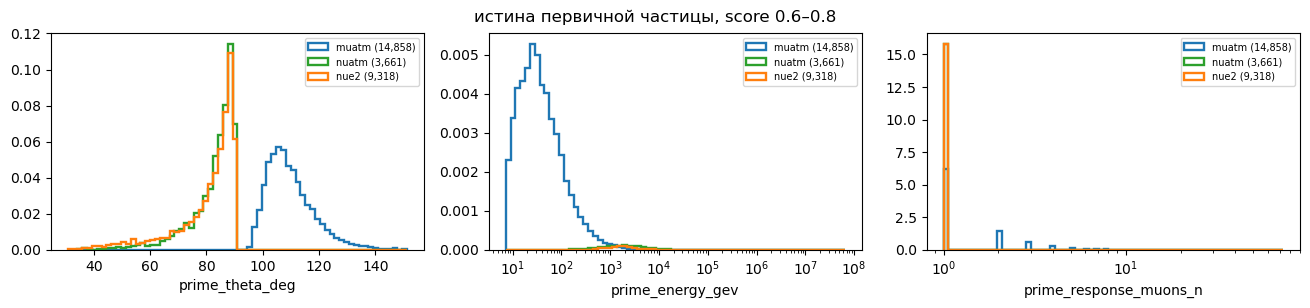

In [37]:
MC = {k: v for k, v in AGG.items() if "prime_theta_deg" in v}
fig = panel(MC, ["prime_theta_deg", "prime_energy_gev", "prime_response_muons_n"],
            ncols=3, prime_energy_gev={"logx": True},
            prime_response_muons_n={"logx": True}, logy=False)
fig.suptitle("истина первичной частицы, score 0.6–0.8", y=1.01)
plt.show()

## 8. Числа

Рисунки показывают форму, таблица — положение. Медианы по каждому домену.

In [12]:
show = ["score", "raw_n_hits", "sig_n_hits", "raw_n_strings", "sig_n_strings",
        "raw_q_mean", "sig_q_mean", "raw_t_std", "sig_t_std", "sig_t_ptp",
        "sig_z_mean", "sig_z_ptp", "prime_theta_deg", "prime_energy_gev"]
table = pd.DataFrame({name: frame.reindex(columns=show).median(numeric_only=True)
                      for name, frame in AGG.items()})
table.round(2)

,exp_full,muatm,nuatm,nue2
score,0.69,0.69,0.73,0.74
raw_n_hits,70.00,83.00,79.00,81.00
sig_n_hits,10.00,10.00,9.00,9.00
raw_n_strings,8.00,8.00,8.00,8.00
sig_n_strings,3.00,3.00,3.00,3.00
raw_q_mean,1.66,1.40,1.34,1.42
sig_q_mean,5.04,4.09,3.79,4.27
raw_t_std,1289.90,1319.65,1336.64,1327.25
sig_t_std,94.04,99.87,98.52,100.18
sig_t_ptp,269.28,287.33,279.44,284.48


## 9. Насколько этим числам можно верить

События внутри одной части — соседи по файлу и потому не независимы: номинальное
число событий переоценивает статистику. Насколько — меряется бутстрапом **по
частям**: части пересобираются с возвращением, медиана пересчитывается, разброс
получившихся значений и есть неопределённость.

Это не украшение. В первой версии ноутбука `muatm` был прорежен вдесятеро, и у
`nuatm` медиана `sig_z_mean` вышла 9.0 против ~47–56 у остальных доменов —
выглядело как яркое различие. На другой половине частей та же величина дала 31.4.
Различия не было, была неустойчивость.

Правило чтения: **отличие между доменами имеет смысл, только если оно превышает
собственную неопределённость обоих.**

In [13]:
def bootstrap(frame, columns, n_draws=300, seed=0):
    """Неопределённость медианы при пересборке выборки ПО ЧАСТЯМ.

    События внутри части не независимы, поэтому обычная ошибка медианы завышает
    точность. Здесь с возвращением пересобираются целые части — это стандартный
    приём для сгруппированных данных, и он даёт настоящий разброс оценки.

    Первая версия этой проверки делила выборку пополам питоновским `hash()`. Он
    солится на каждый процесс, поэтому нарезка была новой при каждом перезапуске
    ядра, и оценка шума сама шумела: у `nue2`, который между прогонами не менялся,
    расхождение по `sig_z_mean` съехало с 10.4 % на 0.2 %.
    """
    columns = [c for c in columns if c in frame]
    values = frame.reindex(columns=columns).apply(
        pd.to_numeric, errors="coerce").to_numpy(float)
    keys = frame["part_key"].astype(str).to_numpy()
    order = np.argsort(keys, kind="stable")
    values, keys = values[order], keys[order]
    edges = np.flatnonzero(np.r_[True, keys[1:] != keys[:-1], True])
    groups = [np.arange(edges[k], edges[k + 1]) for k in range(len(edges) - 1)]

    base = np.nanmedian(values, axis=0)
    rng = np.random.default_rng(seed)
    draws = np.empty((n_draws, values.shape[1]))
    for i in range(n_draws):
        pick = rng.integers(0, len(groups), len(groups))
        draws[i] = np.nanmedian(values[np.concatenate([groups[p] for p in pick])],
                                axis=0)
    relative = draws.std(axis=0) / np.maximum(np.abs(base), 1e-12)
    return pd.Series(relative, index=columns)

# reindex по `show`: у exp_full нет колонок prime_*, поэтому без выравнивания
# порядок индекса разойдётся с таблицей медиан и сравнение отношений упадёт.
spread = pd.DataFrame({name: bootstrap(frame, show)
                       for name, frame in AGG.items()}).reindex(show)
spread.index.name = "неопределённость медианы, % (бутстрап по частям)"
(spread * 100).round(1)

,exp_full,muatm,nuatm,nue2
"неопределённость медианы, % (бутстрап по частям)",,,,
score,0.3,0.1,0.2,0.1
raw_n_hits,2.1,0.3,0.8,0.9
sig_n_hits,4.3,4.5,0.0,1.3
raw_n_strings,0.0,0.0,0.0,0.0
sig_n_strings,0.0,0.0,0.0,0.0
raw_q_mean,1.3,0.3,0.5,0.4
sig_q_mean,2.2,0.7,1.1,0.9
raw_t_std,0.4,0.1,0.1,0.1
sig_t_std,1.2,0.3,0.7,0.4


## 10. Что видно

Ниже отношения медиан к `muatm` сопоставлены с расхождением половин. Колонка
`устойчиво` истинна, когда отличие домена вдвое превышает собственный шум выборки
частей. Это грубое правило, а не статистический критерий, но оно отсекает то, что
обсуждать точно нельзя.

In [14]:
REF = "muatm"
ratio = pd.DataFrame({name: table[name] / table[REF]
                      for name in table.columns if name != REF})


#: Минимальный размер эффекта. Нужен из-за вырожденного случая: у почти
#: постоянных величин (`sig_z_ptp` -- это 60.04 против 60.11) бутстрап даёт
#: неопределённость, округляющуюся в ноль, и тогда порог в две сигмы пропускает
#: отличие в 0.1 %. Нулевое отличие не может быть содержательным, какой бы узкой
#: ни была ошибка.
MIN_EFFECT = 0.05


def verdict_for(column, sigmas=2.0, min_effect=MIN_EFFECT):
    """Отличие от `muatm` против неопределённости самого отношения.

    Относительная ошибка отношения складывается из ошибок обеих медиан в
    квадратуре. Отличие засчитывается, если оно и превышает две такие сигмы, и
    само по себе не меньше `min_effect`.
    """
    noise = pd.Series(np.hypot(spread[REF], spread[column]),
                      index=spread.index).reindex(ratio.index)
    size = (ratio[column] - 1).abs()
    return pd.DataFrame({"к muatm": ratio[column].round(2),
                         "отличие, %": (100 * size).round(1),
                         "±, %": (100 * noise).round(1),
                         "устойчиво": (size > sigmas * noise)
                                      & (size >= min_effect)})

pd.concat({name: verdict_for(name) for name in ratio.columns}, axis=1)

exp_full                              nuatm                               nue2                          
                  к muatm отличие, %  ±, % устойчиво к muatm отличие, %  ±, % устойчиво к muatm отличие, % ±, % устойчиво
score                1.01        1.2   0.3     False    1.06        6.4   0.2      True    1.07        7.4  0.2      True
raw_n_hits           0.84       15.7   2.2      True    0.95        4.8   0.8     False    0.98        2.4  1.0     False
sig_n_hits           1.00        0.0   6.2     False    0.90       10.0   4.5      True    0.90       10.0  4.7      True
raw_n_strings        1.00        0.0   0.0     False    1.00        0.0   0.0     False    1.00        0.0  0.0     False
sig_n_strings        1.00        0.0   0.0     False    1.00        0.0   0.0     False    1.00        0.0  0.0     False
raw_q_mean           1.19       18.7   1.3      True    0.96        4.3   0.6     False    1.01        1.4  0.5     False
sig_q_mean           1.23       23.3   2.3      True    0.93        7.3   1.3      True    1.04        4.4  1.1     False
raw_t_std            0.98        2.3   0.4     False    1.01        1.3   0.1     False    1.01        0.6  0.1     False
sig_t_std            0.94        5.8   1.2      True    0.99        1.3   0.7     False    1.00        0.3  0.5     False
sig_t_ptp            0.94        6.3   0.9      True    0.97        2.7   0.8     False    0.99        1.0  0.5     False
sig_z_mean           1.03        2.5  20.4     False    0.41       59.3  30.2     False    1.21       20.6  6.5      True
sig_z_ptp            1.00        0.1   0.0     False    1.00        0.1   0.0     False    1.00        0.1  0.0     False
prime_theta_deg       NaN        NaN   NaN     False    0.79       21.4   0.2      True    0.78       22.0  0.2      True
prime_energy_gev      NaN        NaN   NaN     False   28.38     2737.7   2.7      True  200.99    19998.6  3.9      True

In [15]:
# `score` исключён: полоса задана именно по нему, так что его близость между
# доменами -- следствие отбора, а не свойство данных.
for name in ratio.columns:
    columns = [c for c in verdict_for(name).query("устойчиво").index
               if c != "score"]
    print(f"{name:<10} устойчивых отличий от muatm: {len(columns)}")
    for column in columns:
        print(f"    {column:<20} x{ratio.loc[column, name]:.2f}"
              f"   (±{100 * np.hypot(spread.loc[column, REF], spread.loc[column, name]):.1f}%)")

exp_full   устойчивых отличий от muatm: 5
    raw_n_hits           x0.84   (±2.2%)
    raw_q_mean           x1.19   (±1.3%)
    sig_q_mean           x1.23   (±2.3%)
    sig_t_std            x0.94   (±1.2%)
    sig_t_ptp            x0.94   (±0.9%)
nuatm      устойчивых отличий от muatm: 4
    sig_n_hits           x0.90   (±4.5%)
    sig_q_mean           x0.93   (±1.3%)
    prime_theta_deg      x0.79   (±0.2%)
    prime_energy_gev     x28.38   (±2.7%)
nue2       устойчивых отличий от muatm: 4
    sig_n_hits           x0.90   (±4.7%)
    sig_z_mean           x1.21   (±6.5%)
    prime_theta_deg      x0.78   (±0.2%)
    prime_energy_gev     x200.99   (±3.9%)


Две оговорки к любым выводам отсюда.

**Полоса 0.6–0.8 — это срез по выходу сети, а не по физике.** Домены в ней уже
отобраны тем, что сеть в них засомневалась, поэтому различия описывают отобранные
подвыборки, а не домены целиком. Утверждать «нейтрино выглядят так» нельзя без
сравнения с полосами вне этой.

**Часть величин неустойчива к выбору частей.** Смотрите таблицу расхождения половин:
всё, где расхождение сравнимо с межсуточным отличием, обсуждать нельзя. Устойчивое
здесь — населённость полосы (нейтрино попадают в неё в десять раз чаще мюонов) и
истина МК, где домены различаются на порядки.

Естественное продолжение — тот же ноутбук для полос `score <= 0.2` и `score > 0.9`
и сопоставление трёх срезов: тогда станет видно, что меняется с ростом скора, а что
одинаково во всех полосах.